# Notebook: CNN para clasificación de ultrasonidos mamarios

Este notebook desarrolla y compara una **CNN entrenada desde cero** y un modelo de
**transfer learning** sobre **BreastMNIST**. La tarea binaria separa lesiones
malignas (clase 0) de imágenes normales o benignas (clase 1).

El flujo incluye auditoría del dataset, tratamiento del desbalance, selección
exclusiva con validación, evaluación final en test e interpretabilidad con Grad-CAM.

⚠️ Este material es educativo. Sus modelos no deben utilizarse para diagnóstico
clínico sin validación externa, controles de sesgo y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
# Ejecutar solo si falta alguna dependencia en el kernel activo.
import importlib.util
import subprocess
import sys

packages = {
    "torch": "torch",
    "torchvision": "torchvision",
    "medmnist": "medmnist",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
}
missing = [pip_name for module, pip_name in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencias disponibles; Python:", sys.version.split()[0])


Dependencias disponibles; Python: 3.11.8


## 3. Cargar el dataset médico (BreastMNIST)

`medmnist` ofrece datasets médicos estandarizados. BreastMNIST contiene imágenes
de ultrasonido mamario reducidas a 28×28 píxeles y particiones oficiales de
train/validación/test. Conservaremos esas particiones durante todo el flujo.


In [2]:
import random
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import medmnist
from medmnist import INFO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

data_flag = "breastmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])
CLASS_NAMES = {int(k): v for k, v in info["label"].items()}
MALIGNANT_CLASS = 0

info


{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


(546, 78, 156)

In [4]:
# Auditoría del dataset: balance y estadísticos calculados solo con train.
def dataset_labels(dataset):
    return np.asarray(dataset.labels).reshape(-1).astype(int)

train_labels = dataset_labels(train_dataset)
val_labels = dataset_labels(val_dataset)
test_labels = dataset_labels(test_dataset)

for split, labels in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    counts = np.bincount(labels, minlength=len(CLASS_NAMES))
    print(f"{split:5s}: n={len(labels):3d} | " +
          " | ".join(f"{CLASS_NAMES[i]}={counts[i]} ({counts[i]/len(labels):.1%})"
                     for i in range(len(counts))))

train_pixels = np.asarray(train_dataset.imgs, dtype=np.float32) / 255.0
TRAIN_MEAN = float(train_pixels.mean())
TRAIN_STD = float(train_pixels.std())
print(f"Train píxeles: media={TRAIN_MEAN:.4f}, std={TRAIN_STD:.4f}, "
      f"min={train_pixels.min():.4f}, max={train_pixels.max():.4f}")


train: n=546 | malignant=147 (26.9%) | normal, benign=399 (73.1%)
val  : n= 78 | malignant=21 (26.9%) | normal, benign=57 (73.1%)
test : n=156 | malignant=42 (26.9%) | normal, benign=114 (73.1%)
Train píxeles: media=0.3276, std=0.2057, min=0.0000, max=1.0000


### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


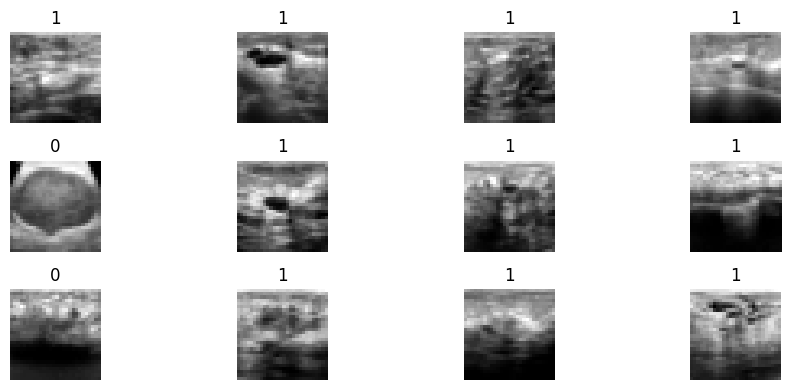

In [5]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
# En Windows, 0 evita errores de serialización dentro de notebooks.
NUM_WORKERS = 0
device


device(type='cpu')

In [7]:
batch_size = 64

def make_loader(dataset, shuffle=False, batch_size=batch_size):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                      generator=generator)

train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset)
test_loader = make_loader(test_dataset)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([64, 1, 28, 28]), torch.Size([64, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [8]:
import torch.nn as nn

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.30), nn.Linear(128 * 2 * 2, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_scratch = SimpleCNN(num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(2, 2))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_feat

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [9]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score)

def logits_to_malignant_probs(logits):
    return torch.softmax(logits, dim=1)[:, MALIGNANT_CLASS]

@torch.no_grad()
def predict(model, loader):
    model.eval()
    labels, probs = [], []
    for x, y in loader:
        logits = model(x.to(device))
        labels.append(y.numpy().reshape(-1).astype(int))
        probs.append(logits_to_malignant_probs(logits).cpu().numpy())
    return np.concatenate(labels), np.concatenate(probs)

def threshold_from_validation(y_true, malignant_prob):
    y_malignant = (y_true == MALIGNANT_CLASS).astype(int)
    candidates = np.unique(np.r_[0.0, malignant_prob, 1.0])
    scores = [balanced_accuracy_score(y_malignant, malignant_prob >= t)
              for t in candidates]
    return float(candidates[int(np.argmax(scores))])

def metrics_from_probs(y_true, malignant_prob, threshold=0.5):
    pred_malignant = malignant_prob >= threshold
    y_pred = np.where(pred_malignant, MALIGNANT_CLASS, 1)
    y_malignant = (y_true == MALIGNANT_CLASS).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_malignant, malignant_prob),
        "pr_auc": average_precision_score(y_malignant, malignant_prob),
        "sensitivity_malignant": cm[0, 0] / cm[0].sum(),
        "specificity_malignant": cm[1, 1] / cm[1].sum(),
        "y_pred": y_pred, "cm": cm,
    }

def evaluate(model, loader, threshold=0.5):
    y_true, malignant_prob = predict(model, loader)
    return metrics_from_probs(y_true, malignant_prob, threshold)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device).long().reshape(-1)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def validation_loss(model, loader, criterion):
    model.eval()
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device).long().reshape(-1)
        losses.append(criterion(model(x), y).item())
    return float(np.mean(losses))

def fit(model, train_loader, val_loader, optimizer, criterion,
        max_epochs=30, patience=7, label="modelo"):
    history = {
        "train_loss": [], "val_loss": [], "val_acc": [],
        "val_bal_acc": [], "val_auc": [],
    }
    best_state, best_auc, stale = None, -np.inf, 0
    for epoch in range(1, max_epochs + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = validation_loss(model, val_loader, criterion)
        val = evaluate(model, val_loader)
        history["train_loss"].append(loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val["accuracy"])
        history["val_bal_acc"].append(val["balanced_accuracy"])
        history["val_auc"].append(val["roc_auc"])
        print(f"{label} {epoch:02d} | train_loss={loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_bal_acc={val['balanced_accuracy']:.4f} | val_auc={val['roc_auc']:.4f}")
        if val["roc_auc"] > best_auc + 1e-4:
            best_auc, stale = val["roc_auc"], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= patience:
                print(f"Early stopping; mejor val_auc={best_auc:.4f}")
                break
    model.load_state_dict(best_state)
    y_val, p_val = predict(model, val_loader)
    return history, threshold_from_validation(y_val, p_val)

class_counts = np.bincount(train_labels, minlength=num_classes)
class_weights = len(train_labels) / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Pesos de clase:", dict(enumerate(class_weights.cpu().numpy().round(3))))


Pesos de clase: {0: np.float32(1.857), 1: np.float32(0.684)}


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)
history_scratch, threshold_scratch = fit(
    model_scratch, train_loader, val_loader, optimizer, criterion,
    max_epochs=30, patience=7, label="Scratch"
)
print(f"Umbral malignidad elegido en validación: {threshold_scratch:.3f}")


Scratch 01 | train_loss=0.6517 | val_loss=0.6883 | val_bal_acc=0.5000 | val_auc=0.7226
Scratch 02 | train_loss=0.5809 | val_loss=0.7371 | val_bal_acc=0.5000 | val_auc=0.7109
Scratch 03 | train_loss=0.5138 | val_loss=0.8599 | val_bal_acc=0.5000 | val_auc=0.8137
Scratch 04 | train_loss=0.4828 | val_loss=0.9445 | val_bal_acc=0.5000 | val_auc=0.8020
Scratch 05 | train_loss=0.4692 | val_loss=1.1194 | val_bal_acc=0.5000 | val_auc=0.8697
Scratch 06 | train_loss=0.4186 | val_loss=0.7582 | val_bal_acc=0.5175 | val_auc=0.8839
Scratch 07 | train_loss=0.4133 | val_loss=0.3239 | val_bal_acc=0.8058 | val_auc=0.9382
Scratch 08 | train_loss=0.3779 | val_loss=0.3545 | val_bal_acc=0.8008 | val_auc=0.9348
Scratch 09 | train_loss=0.3606 | val_loss=0.4545 | val_bal_acc=0.7481 | val_auc=0.9148
Scratch 10 | train_loss=0.3489 | val_loss=0.2797 | val_bal_acc=0.8459 | val_auc=0.9282
Scratch 11 | train_loss=0.2949 | val_loss=0.5242 | val_bal_acc=0.7218 | val_auc=0.9114
Scratch 12 | train_loss=0.2790 | val_loss=0

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


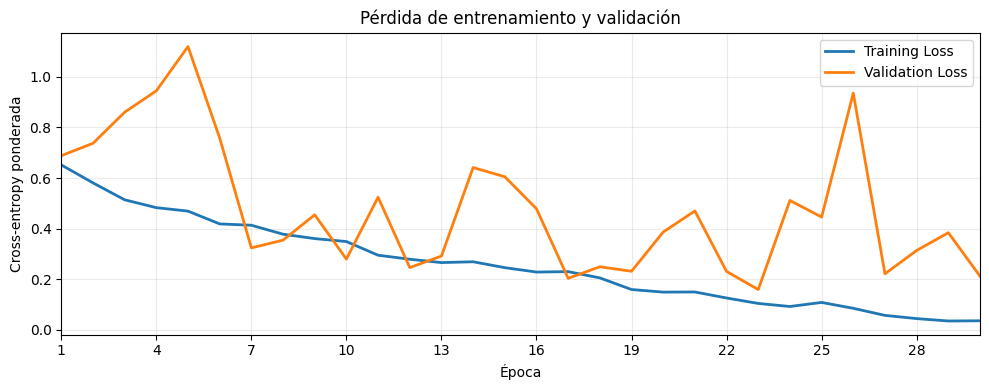

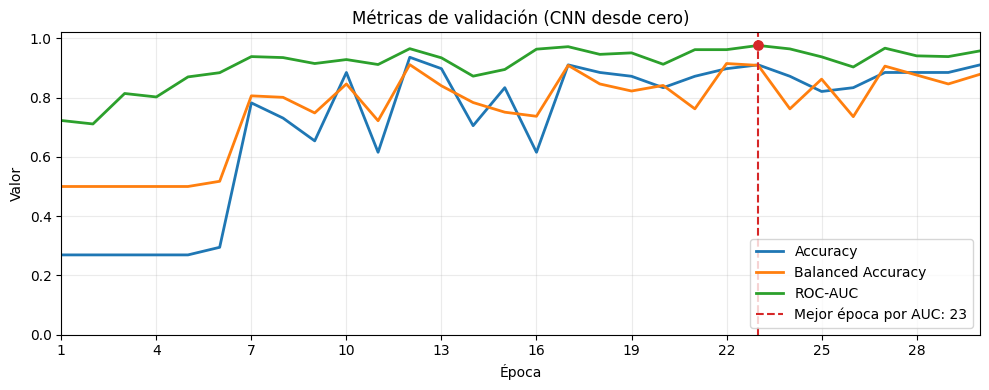

In [11]:
epochs_ran = np.arange(1, len(history_scratch["train_loss"]) + 1)
best_epoch = int(np.argmax(history_scratch["val_auc"])) + 1
tick_step = max(1, int(np.ceil(len(epochs_ran) / 10)))
epoch_ticks = np.arange(1, len(epochs_ran) + 1, tick_step)

plt.figure(figsize=(10, 4))
plt.plot(
    epochs_ran, history_scratch["train_loss"],
    label="Training Loss", color="#1f77b4", linewidth=2,
)
plt.plot(
    epochs_ran, history_scratch["val_loss"],
    label="Validation Loss", color="#ff7f0e", linewidth=2,
)
plt.title("Pérdida de entrenamiento y validación")
plt.xlabel("Época")
plt.ylabel("Cross-entropy ponderada")
plt.xlim(1, len(epochs_ran))
plt.xticks(epoch_ticks)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    epochs_ran, history_scratch["val_acc"],
    label="Accuracy", color="#1f77b4", linewidth=2,
)
plt.plot(
    epochs_ran, history_scratch["val_bal_acc"],
    label="Balanced Accuracy", color="#ff7f0e", linewidth=2,
)
plt.plot(
    epochs_ran, history_scratch["val_auc"],
    label="ROC-AUC", color="#2ca02c", linewidth=2,
)
plt.axvline(
    best_epoch, color="#d62728", linestyle="--", linewidth=1.5,
    label=f"Mejor época por AUC: {best_epoch}",
)
plt.scatter(
    best_epoch, history_scratch["val_auc"][best_epoch - 1],
    color="#d62728", s=45, zorder=3,
)
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.xlim(1, len(epochs_ran))
plt.ylim(0, 1.02)
plt.xticks(epoch_ticks)
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [12]:
result_scratch = evaluate(model_scratch, test_loader, threshold_scratch)
print({k: round(v, 4) for k, v in result_scratch.items()
       if isinstance(v, (float, np.floating))})
y_true, malignant_prob = predict(model_scratch, test_loader)
print(classification_report(y_true, result_scratch["y_pred"],
                            target_names=[CLASS_NAMES[0], CLASS_NAMES[1]],
                            digits=4, zero_division=0))
cm = result_scratch["cm"]
cm


{'accuracy': 0.8718, 'balanced_accuracy': 0.8446, 'roc_auc': 0.9234, 'pr_auc': 0.852, 'sensitivity_malignant': np.float64(0.7857), 'specificity_malignant': np.float64(0.9035)}
                precision    recall  f1-score   support

     malignant     0.7500    0.7857    0.7674        42
normal, benign     0.9196    0.9035    0.9115       114

      accuracy                         0.8718       156
     macro avg     0.8348    0.8446    0.8395       156
  weighted avg     0.8740    0.8718    0.8727       156



array([[ 33,   9],
       [ 11, 103]])

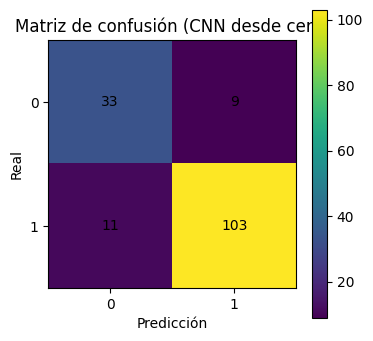

In [13]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [14]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=8),
    T.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    T.ToTensor(),
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = make_loader(train_dataset_aug, shuffle=True)


In [15]:
torch.manual_seed(SEED)
model_aug = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
history_aug, threshold_aug = fit(
    model_aug, train_loader_aug, val_loader, optimizer, criterion,
    max_epochs=30, patience=7, label="Aug"
)
print(f"Umbral malignidad elegido en validación: {threshold_aug:.3f}")


Aug 01 | train_loss=0.6203 | val_loss=0.6755 | val_bal_acc=0.5000 | val_auc=0.7043
Aug 02 | train_loss=0.5571 | val_loss=0.8016 | val_bal_acc=0.5000 | val_auc=0.8271
Aug 03 | train_loss=0.5718 | val_loss=1.1835 | val_bal_acc=0.5000 | val_auc=0.8638
Aug 04 | train_loss=0.5241 | val_loss=0.8571 | val_bal_acc=0.5000 | val_auc=0.8087
Aug 05 | train_loss=0.4897 | val_loss=0.6645 | val_bal_acc=0.5614 | val_auc=0.8596
Aug 06 | train_loss=0.4798 | val_loss=0.4820 | val_bal_acc=0.7281 | val_auc=0.9290
Aug 07 | train_loss=0.4939 | val_loss=0.7368 | val_bal_acc=0.5614 | val_auc=0.8956
Aug 08 | train_loss=0.4459 | val_loss=0.3146 | val_bal_acc=0.8283 | val_auc=0.9273
Aug 09 | train_loss=0.4349 | val_loss=0.2685 | val_bal_acc=0.8459 | val_auc=0.9340
Aug 10 | train_loss=0.4210 | val_loss=0.2750 | val_bal_acc=0.8371 | val_auc=0.9323
Aug 11 | train_loss=0.4771 | val_loss=0.3600 | val_bal_acc=0.7757 | val_auc=0.8755
Aug 12 | train_loss=0.4499 | val_loss=0.2596 | val_bal_acc=0.8434 | val_auc=0.9474
Aug 

### 6.1. Comparación rápida


In [16]:
result_aug = evaluate(model_aug, test_loader, threshold_aug)
for name, result in [("Sin augmentation", result_scratch),
                     ("Con augmentation", result_aug)]:
    print(f"{name:17s} | bal_acc={result['balanced_accuracy']:.4f} | "
          f"auc={result['roc_auc']:.4f} | sens={result['sensitivity_malignant']:.4f} | "
          f"spec={result['specificity_malignant']:.4f}")


Sin augmentation  | bal_acc=0.8446 | auc=0.9234 | sens=0.7857 | spec=0.9035
Con augmentation  | bal_acc=0.8221 | auc=0.8958 | sens=0.7143 | spec=0.9298


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [17]:
import torchvision.models as models

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(8),
    T.RandomAffine(0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std),
])
transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std),
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)
train_loader_tl = make_loader(train_dataset_tl, shuffle=True, batch_size=32)
val_loader_tl = make_loader(val_dataset_tl, batch_size=32)
test_loader_tl = make_loader(test_dataset_tl, batch_size=32)
next(iter(train_loader_tl))[0].shape


torch.Size([32, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [18]:
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(nn.Dropout(0.25), nn.Linear(in_features, num_classes))
for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.fc.parameters():
    param.requires_grad = True
resnet = resnet.to(device)
resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [19]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(resnet.fc.parameters(), lr=1e-3, weight_decay=1e-4)
history_tl_stage1, _ = fit(
    resnet, train_loader_tl, val_loader_tl, optimizer, criterion,
    max_epochs=12, patience=4, label="TL cabeza"
)


TL cabeza 01 | train_loss=0.7285 | val_loss=0.7546 | val_bal_acc=0.4586 | val_auc=0.4119
TL cabeza 02 | train_loss=0.6847 | val_loss=0.7232 | val_bal_acc=0.4223 | val_auc=0.4495
TL cabeza 03 | train_loss=0.6694 | val_loss=0.6294 | val_bal_acc=0.5927 | val_auc=0.6366
TL cabeza 04 | train_loss=0.6552 | val_loss=0.5798 | val_bal_acc=0.6654 | val_auc=0.7435
TL cabeza 05 | train_loss=0.6476 | val_loss=0.5640 | val_bal_acc=0.6654 | val_auc=0.7744
TL cabeza 06 | train_loss=0.6608 | val_loss=0.5432 | val_bal_acc=0.7431 | val_auc=0.7903
TL cabeza 07 | train_loss=0.6466 | val_loss=0.5417 | val_bal_acc=0.6880 | val_auc=0.8028
TL cabeza 08 | train_loss=0.5913 | val_loss=0.5410 | val_bal_acc=0.7030 | val_auc=0.8053
TL cabeza 09 | train_loss=0.6235 | val_loss=0.5298 | val_bal_acc=0.7055 | val_auc=0.7995
TL cabeza 10 | train_loss=0.6635 | val_loss=0.5374 | val_bal_acc=0.7657 | val_auc=0.8062
TL cabeza 11 | train_loss=0.5490 | val_loss=0.5182 | val_bal_acc=0.7544 | val_auc=0.8020
TL cabeza 12 | train_

### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [20]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [21]:
optimizer = torch.optim.AdamW([
    {"params": resnet.layer4.parameters(), "lr": 1e-5},
    {"params": resnet.fc.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
history_tl_stage2, threshold_tl = fit(
    resnet, train_loader_tl, val_loader_tl, optimizer, criterion,
    max_epochs=12, patience=4, label="TL ajuste"
)
print(f"Umbral malignidad elegido en validación: {threshold_tl:.3f}")


TL ajuste 01 | train_loss=0.5771 | val_loss=0.5032 | val_bal_acc=0.7306 | val_auc=0.8154
TL ajuste 02 | train_loss=0.5135 | val_loss=0.4814 | val_bal_acc=0.7431 | val_auc=0.8279
TL ajuste 03 | train_loss=0.5152 | val_loss=0.4890 | val_bal_acc=0.7544 | val_auc=0.8312
TL ajuste 04 | train_loss=0.4995 | val_loss=0.4811 | val_bal_acc=0.7481 | val_auc=0.8413
TL ajuste 05 | train_loss=0.4980 | val_loss=0.4699 | val_bal_acc=0.7331 | val_auc=0.8496
TL ajuste 06 | train_loss=0.4579 | val_loss=0.4665 | val_bal_acc=0.7155 | val_auc=0.8454
TL ajuste 07 | train_loss=0.4869 | val_loss=0.4378 | val_bal_acc=0.7845 | val_auc=0.8638
TL ajuste 08 | train_loss=0.4705 | val_loss=0.4384 | val_bal_acc=0.7393 | val_auc=0.8647
TL ajuste 09 | train_loss=0.4525 | val_loss=0.4234 | val_bal_acc=0.7719 | val_auc=0.8755
TL ajuste 10 | train_loss=0.4570 | val_loss=0.4594 | val_bal_acc=0.7594 | val_auc=0.8755
TL ajuste 11 | train_loss=0.4034 | val_loss=0.3927 | val_bal_acc=0.7782 | val_auc=0.8939
TL ajuste 12 | train_

### 7.3. Evaluación en test del modelo con transfer learning


In [22]:
result_tl = evaluate(resnet, test_loader_tl, threshold_tl)
y_true_tl, y_prob_tl = predict(resnet, test_loader_tl)
y_pred_tl = result_tl["y_pred"]
print({k: round(v, 4) for k, v in result_tl.items()
       if isinstance(v, (float, np.floating))})
print(classification_report(y_true_tl, y_pred_tl,
                            target_names=[CLASS_NAMES[0], CLASS_NAMES[1]],
                            digits=4, zero_division=0))
cm_tl = result_tl["cm"]
cm_tl


{'accuracy': 0.7692, 'balanced_accuracy': 0.7744, 'roc_auc': 0.8757, 'pr_auc': 0.7547, 'sensitivity_malignant': np.float64(0.7857), 'specificity_malignant': np.float64(0.7632)}
                precision    recall  f1-score   support

     malignant     0.5500    0.7857    0.6471        42
normal, benign     0.9062    0.7632    0.8286       114

      accuracy                         0.7692       156
     macro avg     0.7281    0.7744    0.7378       156
  weighted avg     0.8103    0.7692    0.7797       156



array([[33,  9],
       [27, 87]])

### 7.4. Comparación global (resumen)


In [23]:
print("Resumen final en test (test no intervino en selección ni umbrales)")
for name, result in [("CNN sin aug", result_scratch),
                     ("CNN con aug", result_aug),
                     ("ResNet18 TL", result_tl)]:
    print(f"{name:13s} | acc={result['accuracy']:.4f} | "
          f"bal_acc={result['balanced_accuracy']:.4f} | auc={result['roc_auc']:.4f} | "
          f"PR-AUC={result['pr_auc']:.4f} | sens={result['sensitivity_malignant']:.4f} | "
          f"spec={result['specificity_malignant']:.4f}")


Resumen final en test (test no intervino en selección ni umbrales)
CNN sin aug   | acc=0.8718 | bal_acc=0.8446 | auc=0.9234 | PR-AUC=0.8520 | sens=0.7857 | spec=0.9035
CNN con aug   | acc=0.8718 | bal_acc=0.8221 | auc=0.8958 | PR-AUC=0.8073 | sens=0.7143 | spec=0.9298
ResNet18 TL   | acc=0.7692 | bal_acc=0.7744 | auc=0.8757 | PR-AUC=0.7547 | sens=0.7857 | spec=0.7632


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [24]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


C:\Users\Jhunior\AppData\Local\Temp\ipykernel_9808\651962659.py:25: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


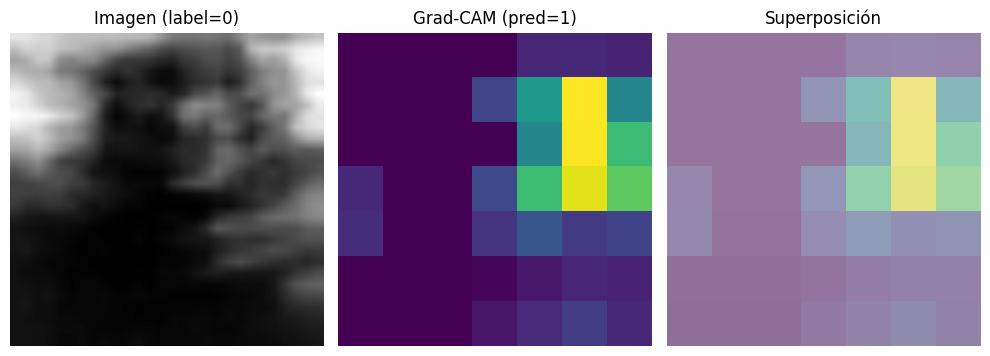

In [25]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy() * imagenet_std[0] + imagenet_mean[0]
img = np.clip(img, 0, 1)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"Imagen (label={int(y.item())})")
axes[1].imshow(cam)
axes[1].set_title(f"Grad-CAM (pred={pred_class})")
axes[2].imshow(img, cmap="gray")
axes[2].imshow(cam, alpha=0.5)
axes[2].set_title("Superposición")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [26]:
import os
os.makedirs("models", exist_ok=True)

torch.save({"state_dict": model_scratch.state_dict(), "threshold": threshold_scratch,
            "class_names": CLASS_NAMES}, "models/cnn_scratch.pth")
torch.save({"state_dict": model_aug.state_dict(), "threshold": threshold_aug,
            "class_names": CLASS_NAMES}, "models/cnn_aug.pth")
torch.save({"state_dict": resnet.state_dict(), "threshold": threshold_tl,
            "class_names": CLASS_NAMES}, "models/resnet_transfer.pth")
["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.
